# QuTiP based workflow

This notebook shows an example of how QuTiP can be used to run calculations on Qbits objects.

In [1]:
import qse
import numpy as np
import matplotlib.pyplot as plt
import qutip as qp

## Step 1: Create qbits object

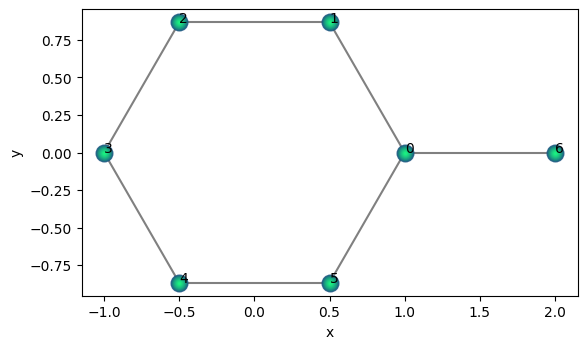

In [2]:
qbits = qse.lattices.ring(1, 6) + qse.Qbits(positions=np.array([[2, 0, 0]]))
qbits.labels = list(range(qbits.nqbits))
qbits.draw(show_labels=True, radius="nearest")

# Step 2: Create the Hamiltonian
Let's looks at the Heisenberg Model
$$
H = - \sum_{<i,j>} (J_{XX}X_i X_j + J_{YY}Y_i Y_j + J_{ZZ}Z_i Z_j)
$$
where $<i,j>$ means only sum over nearest neighbour pairs $i$ and $j$.

We'll measure how the Pauli Z expectation value of each qubit $\langle Z_i \rangle$ varies over time.

In [3]:
def nearest_neigh(d, coupling_str):
    return -coupling_str * (np.abs(d - 1) < 1e-2)


coupling_xx = qbits.compute_interaction_hamiltonian(
    lambda x: nearest_neigh(x, 0.9), "X"
)
coupling_yy = qbits.compute_interaction_hamiltonian(
    lambda x: nearest_neigh(x, 1.1), "Y"
)
coupling_zz = qbits.compute_interaction_hamiltonian(
    lambda x: nearest_neigh(x, 1.0), "Z"
)

couplings = coupling_xx + coupling_yy + coupling_zz
hamiltonian = qse.operators_to_qutip(couplings)

couplings

[-0.90 X0 X1,
 -0.90 X0 X5,
 -0.90 X0 X6,
 -0.90 X1 X2,
 -0.90 X2 X3,
 -0.90 X3 X4,
 -0.90 X4 X5,
 -1.10 Y0 Y1,
 -1.10 Y0 Y5,
 -1.10 Y0 Y6,
 -1.10 Y1 Y2,
 -1.10 Y2 Y3,
 -1.10 Y3 Y4,
 -1.10 Y4 Y5,
 -1.00 Z0 Z1,
 -1.00 Z0 Z5,
 -1.00 Z0 Z6,
 -1.00 Z1 Z2,
 -1.00 Z2 Z3,
 -1.00 Z3 Z4,
 -1.00 Z4 Z5]

In [4]:
times = np.linspace(0, 10, 50)

# Define operators to get expectation values of.
e_ops = [qse.Operator("Z", i, 1.0, qbits.nqbits) for i in range(qbits.nqbits)]
evolved_states = qp.sesolve(
    hamiltonian,
    qp.tensor([qp.fock(2)] * qbits.nqbits),
    tlist=times,
    e_ops=[op.to_qutip() for op in e_ops],
)

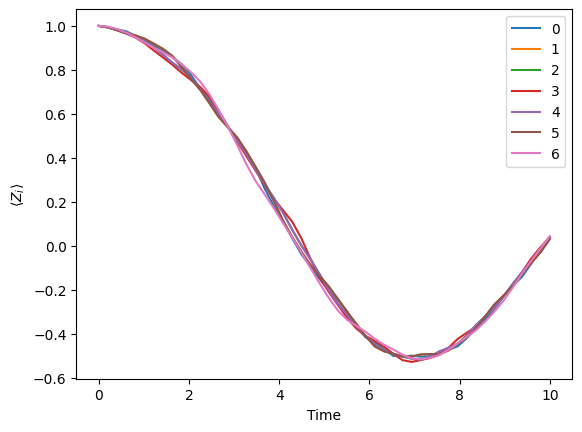

In [5]:
for qb in range(qbits.nqbits):
    plt.plot(times, evolved_states.e_data[qb], label=qb)

plt.ylabel(r"$\langle Z_i \rangle$")
plt.xlabel("Time")
plt.legend()
plt.show()